# LSTM and CNN-LSTM for Human Activity Recognition

## Motivation and aim

Daily activity monitoring requires recognising movement from sequences of sensor readings. Learning directly from these sequences can capture how movement changes over time.

Sensor windows contain temporal patterns that engineered summaries may not preserve. This notebook compares an LSTM, which reads the sequence directly, with a CNN-LSTM, which extracts local patterns before modelling their order.

The comparison asks whether the CNN-LSTM achieves higher validation and benchmark test performance than the LSTM in this experiment.

## Data and evaluation

The [UCI HAR dataset](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones) provides 128-sample windows from nine accelerometer and gyroscope channels. Model settings are selected with separate training and validation participants, then evaluated on the nine official test participants. Raw signals refers to the supplied filtered and windowed sequences before project standardisation.

**Author:** Deepak Kushwaha  
**Course:** Data Mining & Machine Learning

## Contents

1. [Data, validation and normalization](#1-data-validation-and-normalization)
2. [LSTM architecture and selection](#2-lstm-architecture-and-selection)
3. [CNN-LSTM architecture](#3-cnn-lstm-architecture)
4. [CNN-LSTM model selection](#4-cnn-lstm-model-selection)
5. [Final training and test evaluation](#5-final-training-and-test-evaluation)
6. [Decision slices in the learned feature space](#6-decision-slices-in-the-learned-feature-space)
7. [Participant performance and observed errors](#7-participant-performance-and-observed-errors)
8. [Limitations](#8-limitations)
9. [Future work](#9-future-work)

<a id="1-data-validation-and-normalization"></a>

## 1. Data, validation and normalization

The official split contains 21 training and nine test participants. Neural-model selection uses a participant-disjoint validation split: 15 training participants for fitting and six for validation. Whole participants stay together because neighbouring windows overlap.

For each sensor channel, the fitting-participant mean $\mu$ and standard deviation $\sigma$ define

$$z=\frac{x-\mu}{\sigma}.$$

The validation participants do not affect normalization or weight updates. After selecting the architecture and epoch count, statistics are recalculated from all 21 training participants and applied unchanged to the test set. Labels are converted from 1-6 to 0-5, and unweighted cross-entropy is used because class imbalance is mild.

In [18]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

project_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "har_pipeline.py").is_file()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from har_pipeline import load_har_data, channel_statistics, check_raw_windows, ACTIVITIES

SEED = 42
data = load_har_data()
X_train, y_train = data["raw_train"], data["labels_train"]
X_test, y_test = data["raw_test"], data["labels_test"]
subject_train, subject_test = data["subjects_train"], data["subjects_test"]
order = list(ACTIVITIES)
class_names = [name.replace("_", " ").title() for name in order]
class_colors = sns.color_palette("colorblind", 6)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 115, "axes.spines.top": False, "axes.spines.right": False})

splitter = GroupShuffleSplit(n_splits=1, test_size=6, random_state=SEED)
train_idx, val_idx = next(splitter.split(X_train, y_train, subject_train))
X_tr, y_tr = X_train[train_idx], y_train[train_idx]
X_val, y_val = X_train[val_idx], y_train[val_idx]
assert set(subject_train[train_idx]).isdisjoint(subject_train[val_idx])
assert set(subject_train).isdisjoint(subject_test)
assert set(y_tr) == set(y_val) == set(range(1, 7))

display(
    pd.DataFrame(
        [
            {
                "Split": "Selection training",
                "Windows": len(train_idx),
                "Participants": sorted(np.unique(subject_train[train_idx]).tolist()),
            },
            {
                "Split": "Validation",
                "Windows": len(val_idx),
                "Participants": sorted(np.unique(subject_train[val_idx]).tolist()),
            },
            {
                "Split": "Official test",
                "Windows": len(y_test),
                "Participants": sorted(np.unique(subject_test).tolist()),
            },
        ]
    )
)


,Split,Windows,Participants
0,Selection training,5270,"[5, 6, 7, 11, 14, 16, 17, 19, 21, 22, 23, 26, ..."
1,Validation,2082,"[1, 3, 8, 15, 25, 27]"
2,Official test,2947,"[2, 4, 9, 10, 12, 13, 18, 20, 24]"


<a id="2-lstm-architecture-and-selection"></a>

## 2. LSTM architecture and selection

An LSTM updates memory and hidden states across the 128 time steps. Its forget, input and output gates control retained information, new information and the hidden representation.

Three candidates are compared: LSTM-32, LSTM-48-32 and LSTM-64-48. In stacked models, the first layer returns the full sequence and the second uses its final hidden state. Batch normalization follows the first layer, and dropout of 0.5 follows each LSTM. L1 and L2 penalties of 0.01 apply only to the first LSTM's bias values.

All candidates use Adam, batch size 64, at most 30 epochs and early-stopping patience of five. Selection minimizes validation prediction cross-entropy:

$$\mathrm{CE}=-\frac{1}{N}\sum_{i=1}^{N}\log p_{i,y_i}.$$

The selected configuration achieved the lowest validation prediction cross-entropy. This metric excludes regularization penalties; the training loss includes them.

In [19]:
from keras import Sequential
from keras.callbacks import EarlyStopping
from keras.layers import BatchNormalization, Dense, Dropout, Input, LSTM
from keras.regularizers import L1L2
import keras
import tensorflow as tf

tf.config.threading.set_intra_op_parallelism_threads(4)
tf.config.threading.set_inter_op_parallelism_threads(2)

X_keras_train = check_raw_windows(X_train)
X_keras_test = check_raw_windows(X_test)
y_keras_train = (y_train - 1).astype("int64")
y_raw_test = (y_test - 1).astype("int64")
lstm_mean, lstm_std = channel_statistics(X_keras_train[train_idx])
X_lstm_train = (X_keras_train[train_idx] - lstm_mean) / lstm_std
X_lstm_val = (X_keras_train[val_idx] - lstm_mean) / lstm_std
y_lstm_train = y_keras_train[train_idx]
y_lstm_val = y_keras_train[val_idx]

LSTM_CONFIGS = {
    "LSTM-32": [32],
    "LSTM-48-32": [48, 32],
    "LSTM-64-48": [64, 48],
}


def build_lstm(hidden_sizes):
    regularizer = L1L2(l1=0.01, l2=0.01)
    layers = [Input(shape=(128, 9))]
    if len(hidden_sizes) == 1:
        layers.extend([LSTM(hidden_sizes[0]), Dropout(0.5)])
    else:
        layers.extend(
            [
                LSTM(hidden_sizes[0], return_sequences=True, bias_regularizer=regularizer),
                BatchNormalization(),
                Dropout(0.5),
                LSTM(hidden_sizes[1]),
                Dropout(0.5),
            ]
        )
    layers.append(Dense(6, activation="softmax"))
    model = Sequential(layers)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy", keras.metrics.SparseCategoricalCrossentropy(name="prediction_ce")],
    )
    return model


tf.config.experimental.enable_op_determinism()


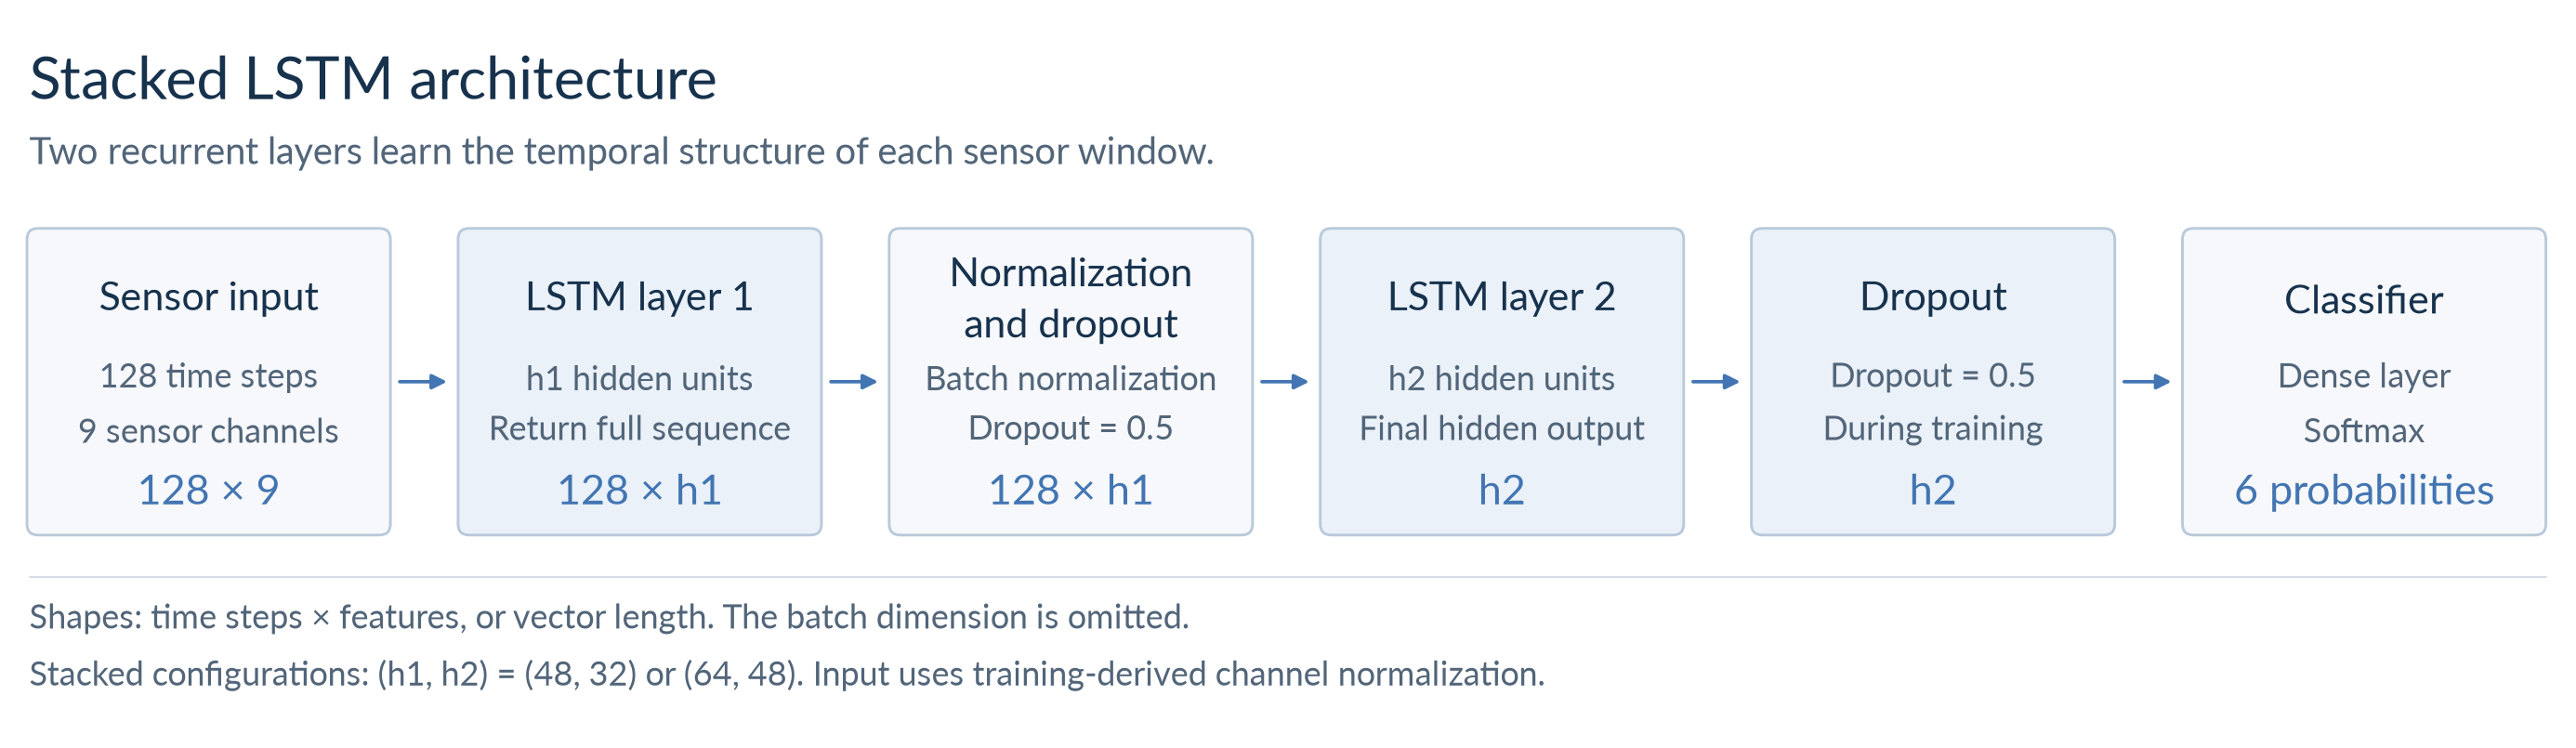

,Architecture,Hidden units,Total parameters
0,LSTM-32,[32],5574
1,LSTM-48-32,"[48, 32]",21894
2,LSTM-64-48,"[64, 48]",41190


In [20]:
from matplotlib import font_manager
from matplotlib.patches import FancyBboxPatch

font_manager.fontManager.addfont(project_root / "assets/fonts/Lato-Regular.ttf")


def draw_architecture(blocks, title, subtitle, note):
    """Draw the model flow with output shapes and no batch dimension."""
    navy, blue, muted = "#17324D", "#4275B2", "#526579"
    fig, ax = plt.subplots(figsize=(16, 4.5), dpi=180)
    fig.patch.set_facecolor("white")
    fig.subplots_adjust(left=0.025, right=0.975, top=0.98, bottom=0.03)
    ax.set(xlim=(-0.08, 16.08), ylim=(0, 4.5))
    ax.axis("off")

    def label(x, y, text, size, color=navy, align="left", **kwargs):
        return ax.text(
            x,
            y,
            text,
            fontsize=size,
            color=color,
            fontfamily="Lato",
            ha=align,
            va="center",
            **kwargs
        )

    label(0, 4.12, title, 25)
    label(0, 3.66, subtitle, 16, muted)
    width, gap, bottom, height = 2.28, 0.46, 1.25, 1.9
    for i, (name, detail, shape) in enumerate(blocks):
        x = i * (width + gap)
        fill = "#EAF1F9" if i in (1, 3, 4) else "#F6F8FB"
        box = FancyBboxPatch(
            (x, bottom),
            width,
            height,
            boxstyle="round,pad=0.015,rounding_size=0.07",
            facecolor=fill,
            edgecolor="#B8C9DA",
            linewidth=1.15,
        )
        ax.add_patch(box)
        label(x + width / 2, 2.72, name, 17, align="center", linespacing=1.15)
        label(x + width / 2, 2.06, detail, 14.5, muted, "center", linespacing=1.3)
        label(x + width / 2, 1.53, shape, 18, blue, "center")
        if i < len(blocks) - 1:
            ax.annotate(
                "",
                xy=(x + width + gap - 0.055, 2.2),
                xytext=(x + width + 0.045, 2.2),
                arrowprops=dict(arrowstyle="-|>", color=blue, lw=1.5, mutation_scale=13),
            )
    ax.plot([0, 16], [0.97, 0.97], color="#D5DFE9", lw=0.8)
    label(0, 0.53, note, 14.5, muted, linespacing=1.4)
    return fig


fig = draw_architecture(
    [
        ("Sensor input", "128 time steps\n9 sensor channels", "128 × 9"),
        ("LSTM layer 1", "h1 hidden units\nReturn full sequence", "128 × h1"),
        ("Normalization\nand dropout", "Batch normalization\nDropout = 0.5", "128 × h1"),
        ("LSTM layer 2", "h2 hidden units\nFinal hidden output", "h2"),
        ("Dropout", "Dropout = 0.5\nDuring training", "h2"),
        ("Classifier", "Dense layer\nSoftmax", "6 probabilities"),
    ],
    "Stacked LSTM architecture",
    "Two recurrent layers learn the temporal structure of each sensor window.",
    "Shapes: time steps × features, or vector length. The batch dimension is omitted.\n"
    "Stacked configurations: (h1, h2) = (48, 32) or (64, 48). Input uses training-derived channel normalization.",
)
plt.show()

lstm_architectures = []
for name, units in LSTM_CONFIGS.items():
    preview = build_lstm(units)
    lstm_architectures.append(
        {
            "Architecture": name,
            "Hidden units": str(units),
            "Total parameters": preview.count_params(),
        }
    )
display(pd.DataFrame(lstm_architectures))


In [21]:
lstm_runs = {}
for name, hidden_sizes in LSTM_CONFIGS.items():
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)
    candidate = build_lstm(hidden_sizes)
    history = candidate.fit(
        X_lstm_train,
        y_lstm_train,
        validation_data=(X_lstm_val, y_lstm_val),
        epochs=30,
        batch_size=64,
        verbose=0,
        callbacks=[
            EarlyStopping(
                monitor="val_prediction_ce", mode="min", patience=5, restore_best_weights=True
            )
        ],
    )
    best_epoch = int(np.argmin(history.history["val_prediction_ce"]))
    lstm_runs[name] = {
        "history": history.history,
        "best_val_ce": history.history["val_prediction_ce"][best_epoch],
        "best_val_accuracy": history.history["val_accuracy"][best_epoch],
        "best_epoch": best_epoch + 1,
    }
    print(
        f"{name}: CE={lstm_runs[name]['best_val_ce']:.4f}, "
        f"accuracy={lstm_runs[name]['best_val_accuracy']:.4f}, epoch={best_epoch + 1}"
    )
selected_lstm_name = min(lstm_runs, key=lambda name: lstm_runs[name]["best_val_ce"])
selected_epoch_count = lstm_runs[selected_lstm_name]["best_epoch"]
print("Selected:", selected_lstm_name, "for", selected_epoch_count, "epochs")


E0000 00:00:1789479809.796442 3656472 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


LSTM-32: CE=0.3068, accuracy=0.9342, epoch=5


E0000 00:00:1789479825.892877 3656472 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1789479832.310741 3656472 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

LSTM-48-32: CE=0.1203, accuracy=0.9616, epoch=8


E0000 00:00:1789479882.057058 3656472 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1789479889.229251 3656472 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

LSTM-64-48: CE=0.0883, accuracy=0.9755, epoch=20
Selected: LSTM-64-48 for 20 epochs


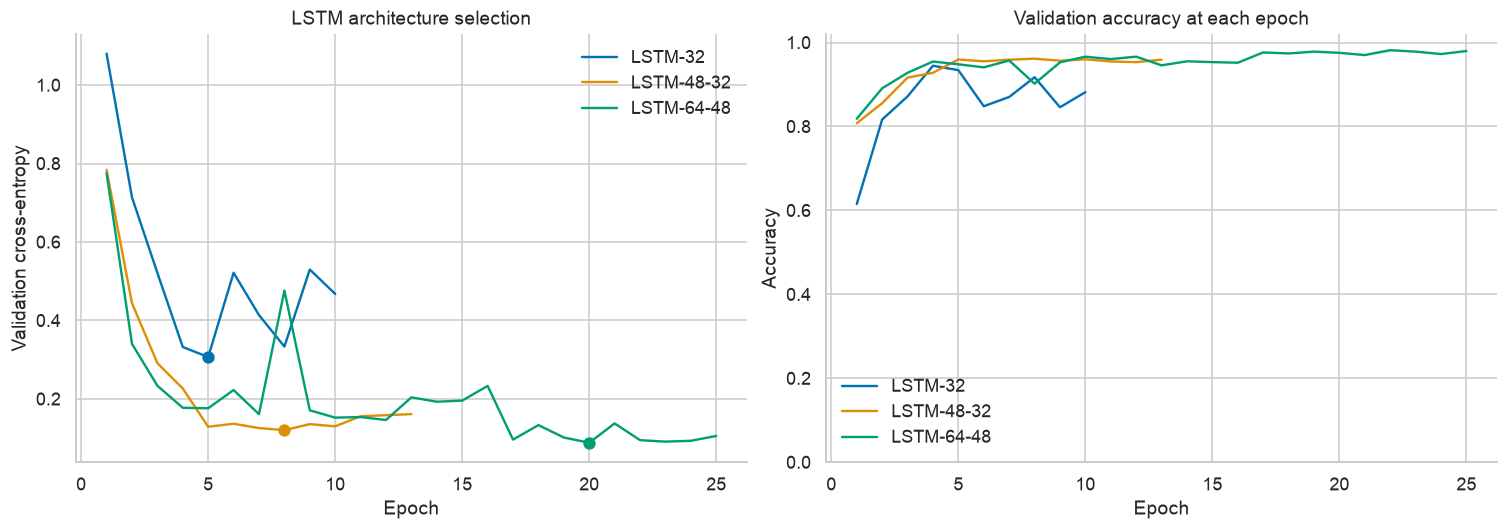

The lowest validation cross-entropy belongs to **LSTM-64-48** at epoch **20**: 0.0883. Its validation accuracy at that checkpoint is 97.55%. The dots mark the minimum cross-entropy for each architecture.

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")
for color, (name, run) in zip(class_colors, lstm_runs.items()):
    epochs = np.arange(1, len(run["history"]["loss"]) + 1)
    axes[0].plot(epochs, run["history"]["val_prediction_ce"], color=color, label=name)
    axes[0].scatter(run["best_epoch"], run["best_val_ce"], color=color, s=45, zorder=3)
    axes[1].plot(epochs, run["history"]["val_accuracy"], color=color, label=name)
axes[0].set(title="LSTM architecture selection", xlabel="Epoch", ylabel="Validation cross-entropy")
axes[1].set(
    title="Validation accuracy at each epoch", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1.02)
)
for ax in axes:
    ax.legend(frameon=False)
plt.show()
selected_run = lstm_runs[selected_lstm_name]
display(
    Markdown(
        f"The lowest validation cross-entropy belongs to **{selected_lstm_name}** "
        f"at epoch **{selected_epoch_count}**: {selected_run['best_val_ce']:.4f}. "
        f"Its validation accuracy at that checkpoint is {selected_run['best_val_accuracy']:.2%}. "
        "The dots mark the minimum cross-entropy for each architecture."
    )
)


<a id="3-cnn-lstm-architecture"></a>

## 3. CNN-LSTM architecture

Two Conv1D layers use 64 filters with kernel size 5 and preserve 128 time steps. Max pooling reduces the sequence to 64 steps, then a third Conv1D layer produces 128 features with kernel size 3. Batch normalization and ReLU follow each convolution.

The LSTM reads the 64-step feature sequence. Its final hidden vector passes through dropout and a six-output linear layer. Cross-entropy operates on these logits, so no softmax layer is included in the model.

The shape check below uses 64 LSTM units. Model selection later compares 32, 64 and 128 units while keeping the convolutional stack fixed.

,Layer,"Output (batch, channels, time)",Trainable parameters
0,1. Conv1d,"(2, 64, 128)",2944
1,2. BatchNorm1d,"(2, 64, 128)",128
2,3. ReLU,"(2, 64, 128)",0
3,4. Conv1d,"(2, 64, 128)",20544
4,5. BatchNorm1d,"(2, 64, 128)",128
5,6. ReLU,"(2, 64, 128)",0
6,7. MaxPool1d,"(2, 64, 64)",0
7,8. Conv1d,"(2, 128, 64)",24704
8,9. BatchNorm1d,"(2, 128, 64)",256
9,10. ReLU,"(2, 128, 64)",0


CNN parameters: 48704
LSTM parameters: 49664
Classification head parameters: 390


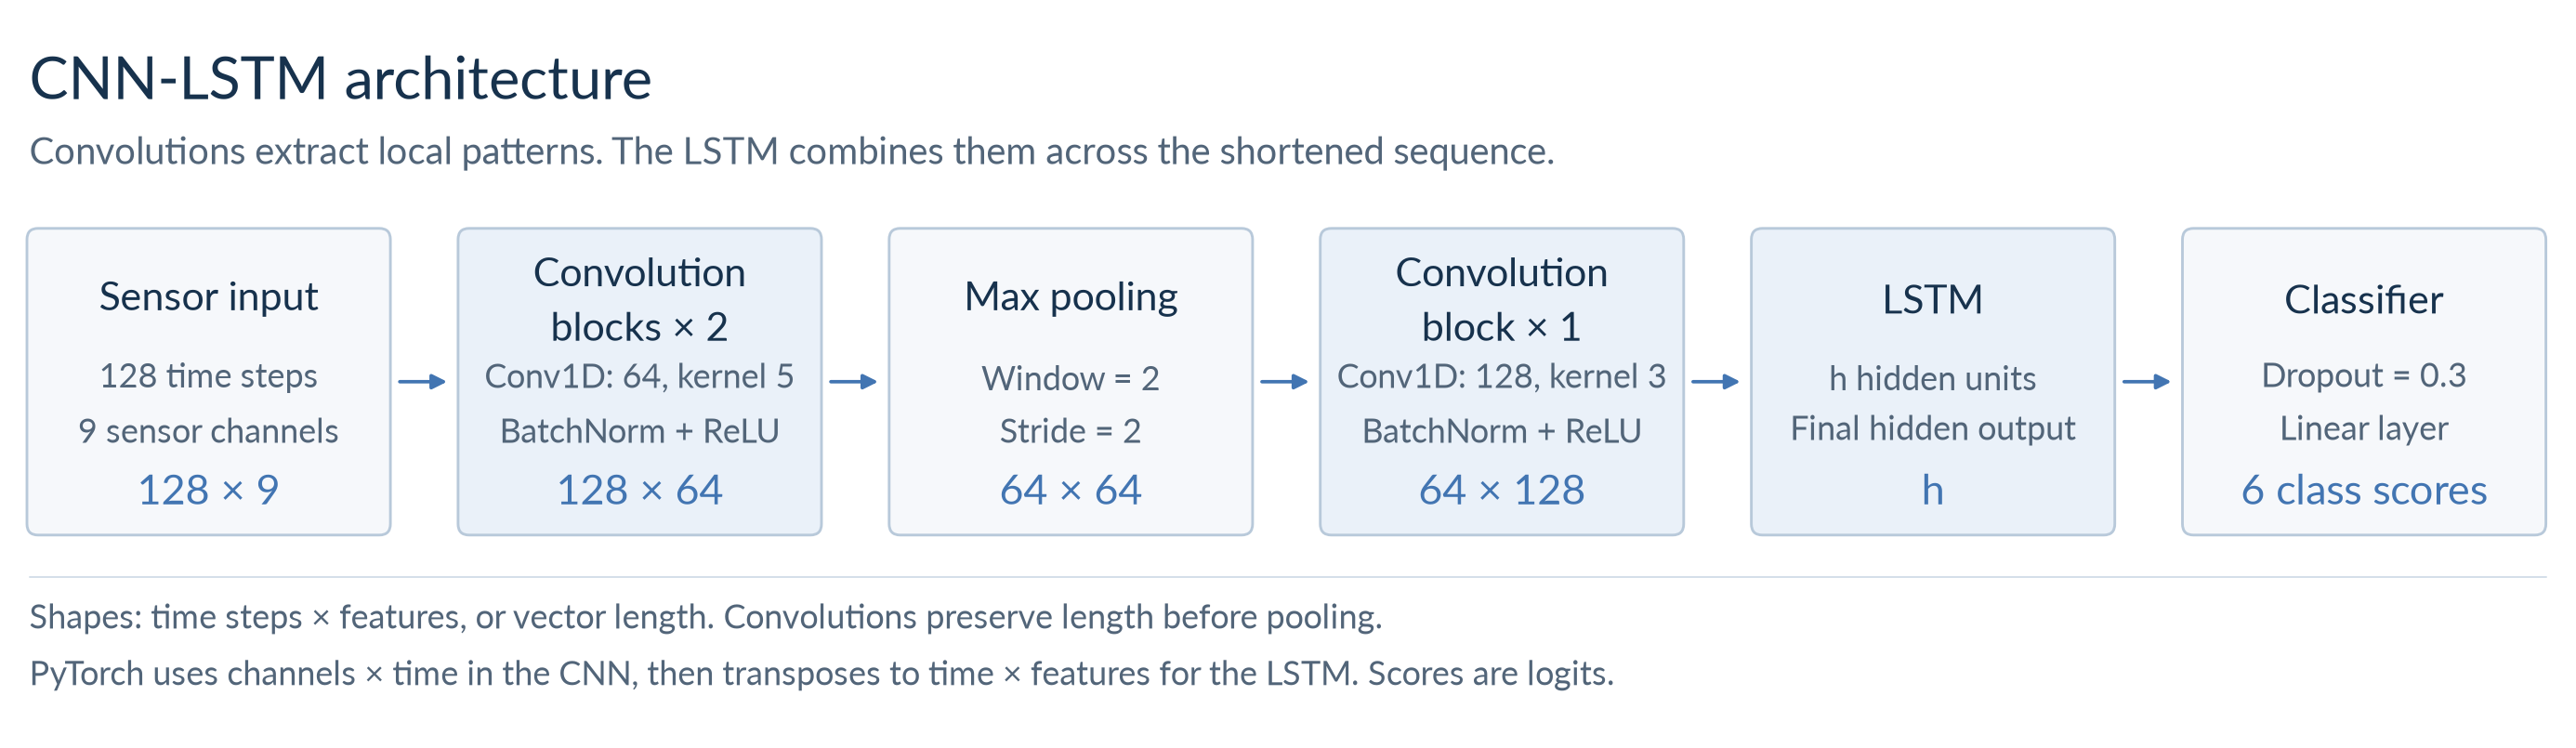

In [23]:
import torch

torch.set_num_threads(4)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

selection_mean, selection_std = (value.reshape(9) for value in channel_statistics(X_tr))


def to_tensors(windows, labels, mean, std):
    scaled = (windows - mean) / std
    channels_first = np.ascontiguousarray(scaled.transpose(0, 2, 1))
    return torch.tensor(channels_first, dtype=torch.float32), torch.tensor(
        labels - 1, dtype=torch.long
    )


X_tr_t, y_tr_t = to_tensors(X_tr, y_tr, selection_mean, selection_std)
X_val_t, y_val_t = to_tensors(X_val, y_val, selection_mean, selection_std)


class CNN(nn.Module):
    def __init__(self, n_channels=9):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )

    def forward(self, windows):
        return self.features(windows)


class CNNLSTM(nn.Module):
    def __init__(self, n_channels=9, n_classes=6, hidden_size=64, dropout=0.3):
        super().__init__()
        self.cnn = CNN(n_channels)
        self.lstm = nn.LSTM(128, hidden_size, batch_first=True)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_size, n_classes))

    def encode(self, windows):
        sequence = self.cnn(windows).transpose(1, 2)
        _, (hidden, _) = self.lstm(sequence)
        return hidden[-1]

    def forward(self, windows):
        return self.head(self.encode(windows))


torch.manual_seed(SEED)
preview = CNNLSTM().eval()
shape_rows = []
with torch.no_grad():
    features = torch.zeros(2, 9, 128)
    for index, layer in enumerate(preview.cnn.features):
        features = layer(features)
        shape_rows.append(
            {
                "Layer": f"{index + 1}. {type(layer).__name__}",
                "Output (batch, channels, time)": str(tuple(features.shape)),
                "Trainable parameters": sum(p.numel() for p in layer.parameters()),
            }
        )
    assert features.shape == (2, 128, 64)
    assert preview(torch.zeros(2, 9, 128)).shape == (2, 6)
display(pd.DataFrame(shape_rows))
print("CNN parameters:", sum(p.numel() for p in preview.cnn.parameters()))
print("LSTM parameters:", sum(p.numel() for p in preview.lstm.parameters()))
print("Classification head parameters:", sum(p.numel() for p in preview.head.parameters()))

fig = draw_architecture(
    [
        ("Sensor input", "128 time steps\n9 sensor channels", "128 × 9"),
        ("Convolution\nblocks × 2", "Conv1D: 64, kernel 5\nBatchNorm + ReLU", "128 × 64"),
        ("Max pooling", "Window = 2\nStride = 2", "64 × 64"),
        ("Convolution\nblock × 1", "Conv1D: 128, kernel 3\nBatchNorm + ReLU", "64 × 128"),
        ("LSTM", "h hidden units\nFinal hidden output", "h"),
        ("Classifier", "Dropout = 0.3\nLinear layer", "6 class scores"),
    ],
    "CNN-LSTM architecture",
    "Convolutions extract local patterns. The LSTM combines them across the shortened sequence.",
    "Shapes: time steps × features, or vector length. Convolutions preserve length before pooling.\n"
    "PyTorch uses channels × time in the CNN, then transposes to time × features for the LSTM. Scores are logits.",
)
plt.show()


<a id="4-cnn-lstm-model-selection"></a>

## 4. CNN-LSTM model selection

A one-pass coordinate search compares hidden sizes 32, 64 and 128, learning rates 0.001 and 0.0005, and dropout 0.2, 0.3 and 0.5. Weight decay remains 0.0001.

Hidden size controls the LSTM's capacity, learning rate controls the size of weight updates, and head dropout regularizes the classifier. All three can affect performance on the validation participants.

One setting changes at a time, and the best carries into the next stage. The six runs can miss interactions between settings. Each run stops after seven epochs without validation improvement, up to 30 epochs. The lowest validation cross-entropy selects both the configuration and final epoch count.

Training uses dropout and changing parameters, while validation uses evaluation mode. Validation loss can therefore fall below training loss without leakage.

In [24]:
def train_config(hidden_size=64, lr=1e-3, dropout=0.3, batch_size=64, max_epochs=30, patience=7):
    """Return validation scores and epoch history for one configuration."""
    torch.manual_seed(SEED)
    tr_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=256)

    net = CNNLSTM(hidden_size=hidden_size, dropout=dropout)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    def run(loader, train):
        net.train(train)
        total_loss, correct, n = 0.0, 0, 0
        for xb, yb in loader:
            with torch.set_grad_enabled(train):
                out = net(xb)
                loss = loss_fn(out, yb)
                if train:
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
            total_loss += loss.item() * len(xb)
            correct += (out.argmax(1) == yb).sum().item()
            n += len(xb)
        return total_loss / n, correct / n

    history = []
    best_loss, best_acc, wait = float("inf"), 0.0, 0
    for epoch in range(1, max_epochs + 1):
        tr_loss, tr_acc = run(tr_loader, train=True)
        val_loss, val_acc = run(va_loader, train=False)
        history.append((tr_loss, tr_acc, val_loss, val_acc))
        if val_loss < best_loss:
            best_loss, best_acc = val_loss, val_acc
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break
    return best_loss, best_acc, history


In [25]:
tuning_results = []
current = dict(hidden_size=64, lr=1e-3, dropout=0.3)
best_val_loss_tune, best_val_acc_tune = float("inf"), 0.0
tuned_history, best_config = None, dict(current)

sweeps = [("hidden_size", [32, 64, 128]), ("lr", [1e-3, 5e-4]), ("dropout", [0.2, 0.3, 0.5])]

for param, values in sweeps:
    for value in values:
        cfg = {**current, param: value}
        seen = {(r["hidden_size"], r["lr"], r["dropout"]) for r in tuning_results}
        if (cfg["hidden_size"], cfg["lr"], cfg["dropout"]) in seen:
            continue
        val_loss, val_acc, history = train_config(**cfg)
        tuning_results.append(
            {**cfg, "epochs": len(history), "val_loss": val_loss, "val_acc": val_acc}
        )
        print(
            f"hidden {cfg['hidden_size']:3d}  lr {cfg['lr']:.0e}  dropout {cfg['dropout']}"
            f"  ->  val loss {val_loss:.3f}  val acc {val_acc:.3f}  ({len(history)} epochs)"
        )
        if val_loss < best_val_loss_tune:
            best_val_loss_tune, best_val_acc_tune = val_loss, val_acc
            tuned_history, best_config = history, dict(cfg)
    current = dict(best_config)

results_table = (
    pd.DataFrame(tuning_results)
    .sort_values("val_loss")
    .reset_index(drop=True)
    .round({"val_loss": 3, "val_acc": 3})
)
results_table


hidden  32  lr 1e-03  dropout 0.3  ->  val loss 0.098  val acc 0.970  (18 epochs)
hidden  64  lr 1e-03  dropout 0.3  ->  val loss 0.095  val acc 0.972  (11 epochs)
hidden 128  lr 1e-03  dropout 0.3  ->  val loss 0.081  val acc 0.977  (11 epochs)
hidden 128  lr 5e-04  dropout 0.3  ->  val loss 0.106  val acc 0.959  (15 epochs)
hidden 128  lr 1e-03  dropout 0.2  ->  val loss 0.099  val acc 0.971  (10 epochs)
hidden 128  lr 1e-03  dropout 0.5  ->  val loss 0.111  val acc 0.955  (13 epochs)


,hidden_size,lr,dropout,epochs,val_loss,val_acc
0,128,0.0010,0.3,11,0.081,0.977
1,64,0.0010,0.3,11,0.095,0.972
2,32,0.0010,0.3,18,0.098,0.970
3,128,0.0010,0.2,10,0.099,0.971
4,128,0.0005,0.3,15,0.106,0.959
5,128,0.0010,0.5,13,0.111,0.955


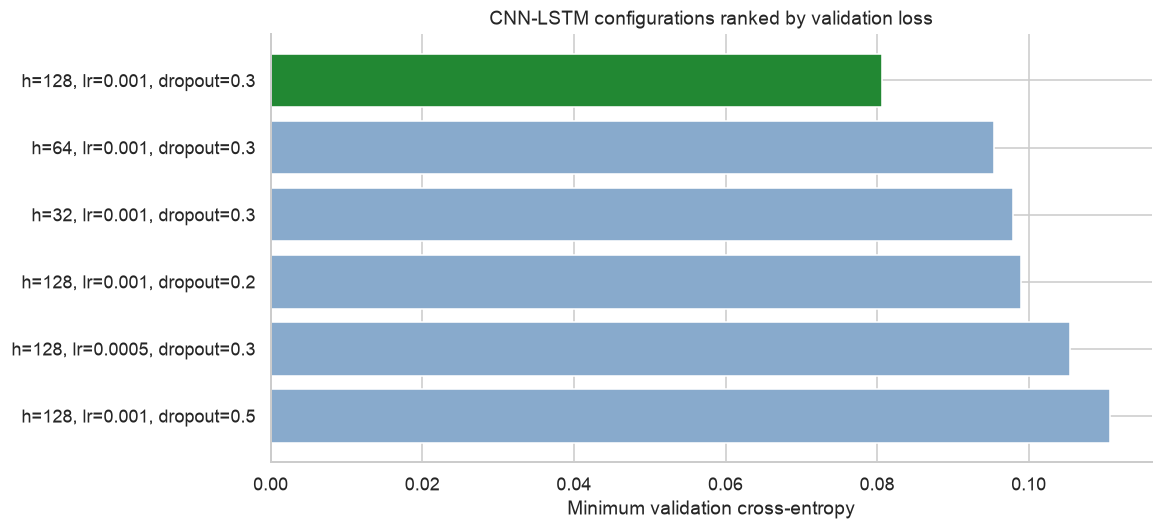

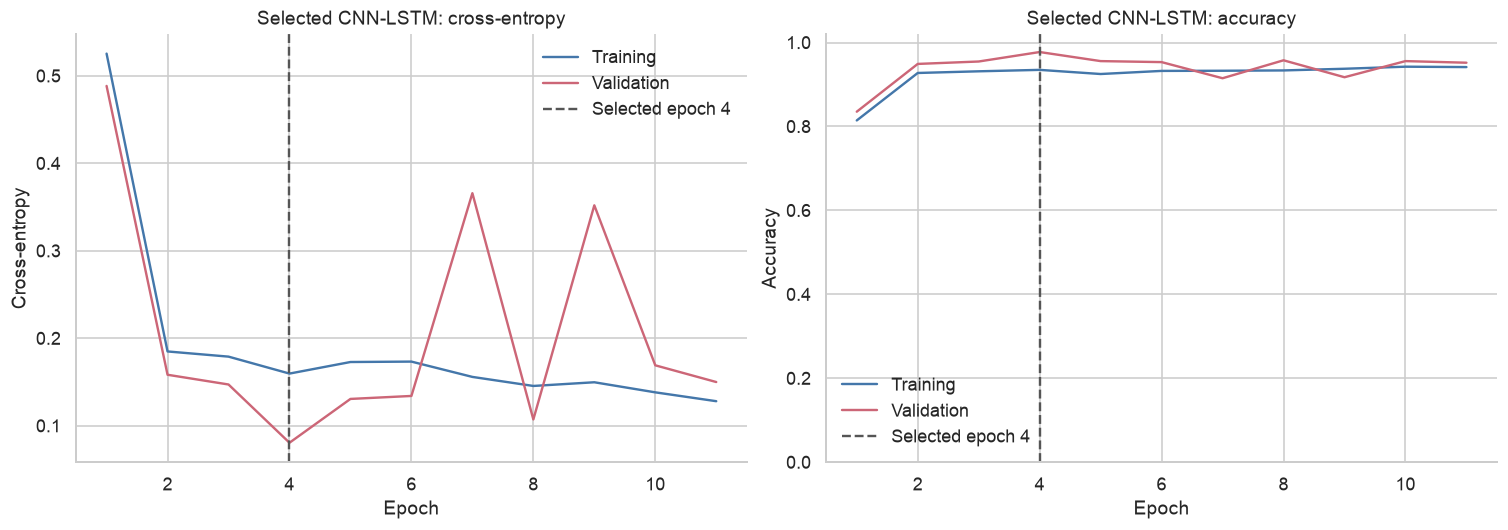

The selected CNN-LSTM has **128 hidden units**, learning rate **0.001**, and head dropout **0.3**. Its minimum validation cross-entropy is **0.0806**, at epoch **4**. Training accuracy includes dropout and changing batch statistics; validation uses evaluation mode. A higher validation accuracy on some epochs is therefore possible.

In [26]:
ranked = pd.DataFrame(tuning_results).sort_values("val_loss").reset_index(drop=True)
labels = [f"h={r.hidden_size:g}, lr={r.lr:g}, dropout={r.dropout:g}" for r in ranked.itertuples()]
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
ax.barh(labels, ranked.val_loss, color=["#228833"] + ["#88aacc"] * (len(ranked) - 1))
ax.invert_yaxis()
ax.set(
    title="CNN-LSTM configurations ranked by validation loss",
    xlabel="Minimum validation cross-entropy",
)
plt.show()

history_array = np.asarray(tuned_history)
epochs = np.arange(1, len(history_array) + 1)
best_ep = int(history_array[:, 2].argmin()) + 1
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")
for ax, train_column, val_column, ylabel in [
    (axes[0], 0, 2, "Cross-entropy"),
    (axes[1], 1, 3, "Accuracy"),
]:
    ax.plot(epochs, history_array[:, train_column], label="Training", color="#4477aa")
    ax.plot(epochs, history_array[:, val_column], label="Validation", color="#cc6677")
    ax.axvline(best_ep, color="#555555", ls="--", label=f"Selected epoch {best_ep}")
    ax.set(xlabel="Epoch", ylabel=ylabel, title=f"Selected CNN-LSTM: {ylabel.lower()}")
    ax.legend(frameon=False)
axes[1].set_ylim(0, 1.02)
plt.show()
display(
    Markdown(
        f"The selected CNN-LSTM has **{best_config['hidden_size']} hidden units**, "
        f"learning rate **{best_config['lr']}**, and head dropout **{best_config['dropout']}**. "
        f"Its minimum validation cross-entropy is **{best_val_loss_tune:.4f}**, at epoch **{best_ep}**. "
        "Training accuracy includes dropout and changing batch statistics; validation uses evaluation mode. "
        "A higher validation accuracy on some epochs is therefore possible."
    )
)


<a id="5-final-training-and-test-evaluation"></a>

## 5. Final training and test evaluation

Each selected network is reinitialised and trained on all 21 training participants. Normalization is recalculated from those participants, and the validation-selected epoch count is used without further early stopping.

The official test scores are benchmark results because the test set was inspected during development. Accuracy, macro-F1, confusion matrices and participant-level scores describe performance from this run. The recorded run selects LSTM-64-48 for 20 epochs and CNN-LSTM with 128 hidden units, learning rate 0.001 and dropout 0.3 for four epochs.

In [27]:
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)
lstm_mean, lstm_std = channel_statistics(X_keras_train)
selected_lstm = build_lstm(LSTM_CONFIGS[selected_lstm_name])
selected_lstm.fit(
    (X_keras_train - lstm_mean) / lstm_std,
    y_keras_train,
    epochs=selected_epoch_count,
    batch_size=64,
    verbose=0,
)
print("LSTM refit complete; CNN-LSTM refit and test evaluation follow.")


E0000 00:00:1789480644.715386 3656472 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


LSTM refit complete; CNN-LSTM refit and test evaluation follow.


In [28]:
# Freeze the epoch budget from the best validation checkpoint.
final_epochs = int(np.argmin(np.asarray(tuned_history)[:, 2])) + 1
torch.manual_seed(SEED)
final_mean, final_std = (v.reshape(9) for v in channel_statistics(X_train))
assert np.isfinite(final_std).all() and (final_std > 1e-8).all()
X_all_t, y_all_t = to_tensors(X_train, y_train, final_mean, final_std)
final_loader = DataLoader(TensorDataset(X_all_t, y_all_t), batch_size=64, shuffle=True)
tuned_model = CNNLSTM(hidden_size=best_config["hidden_size"], dropout=best_config["dropout"])
final_optimizer = torch.optim.Adam(
    tuned_model.parameters(), lr=best_config["lr"], weight_decay=1e-4
)
for epoch in range(final_epochs):
    tuned_model.train()
    for xb, yb in final_loader:
        final_optimizer.zero_grad()
        loss = nn.CrossEntropyLoss()(tuned_model(xb), yb)
        loss.backward()
        final_optimizer.step()
print(
    "Final training:",
    len(X_train),
    "windows from",
    len(set(subject_train)),
    "subjects,",
    final_epochs,
    "epochs",
)

X_test_t, y_test_t = to_tensors(X_test, y_test, final_mean, final_std)
test_true = y_test - 1

tuned_model.eval()
with torch.no_grad():
    test_pred = np.concatenate(
        [tuned_model(X_test_t[i : i + 128]).argmax(1).numpy() for i in range(0, len(X_test_t), 128)]
    )

test_acc = (test_pred == test_true).mean()
test_f1 = f1_score(test_true, test_pred, average="macro")

print("config       :", best_config)
print(f"test accuracy: {test_acc:.3f}")
print(f"test macro-F1: {test_f1:.3f}")
print()
print(classification_report(test_true, test_pred, target_names=order, digits=3))


Final training: 7352 windows from 21 subjects, 4 epochs
config       : {'hidden_size': 128, 'lr': 0.001, 'dropout': 0.3}
test accuracy: 0.927
test macro-F1: 0.928

                    precision    recall  f1-score   support

           WALKING      0.963     1.000     0.981       496
  WALKING_UPSTAIRS      0.987     0.932     0.959       471
WALKING_DOWNSTAIRS      0.965     0.998     0.981       420
           SITTING      0.793     0.849     0.820       491
          STANDING      0.863     0.795     0.828       532
            LAYING      1.000     1.000     1.000       537

          accuracy                          0.927      2947
         macro avg      0.929     0.929     0.928      2947
      weighted avg      0.928     0.927     0.926      2947



E0000 00:00:1789480825.962470 3656472 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,Accuracy,Macro-F1
Model,,
LSTM-64-48,0.9118,0.9119
CNN-LSTM,0.9267,0.9281


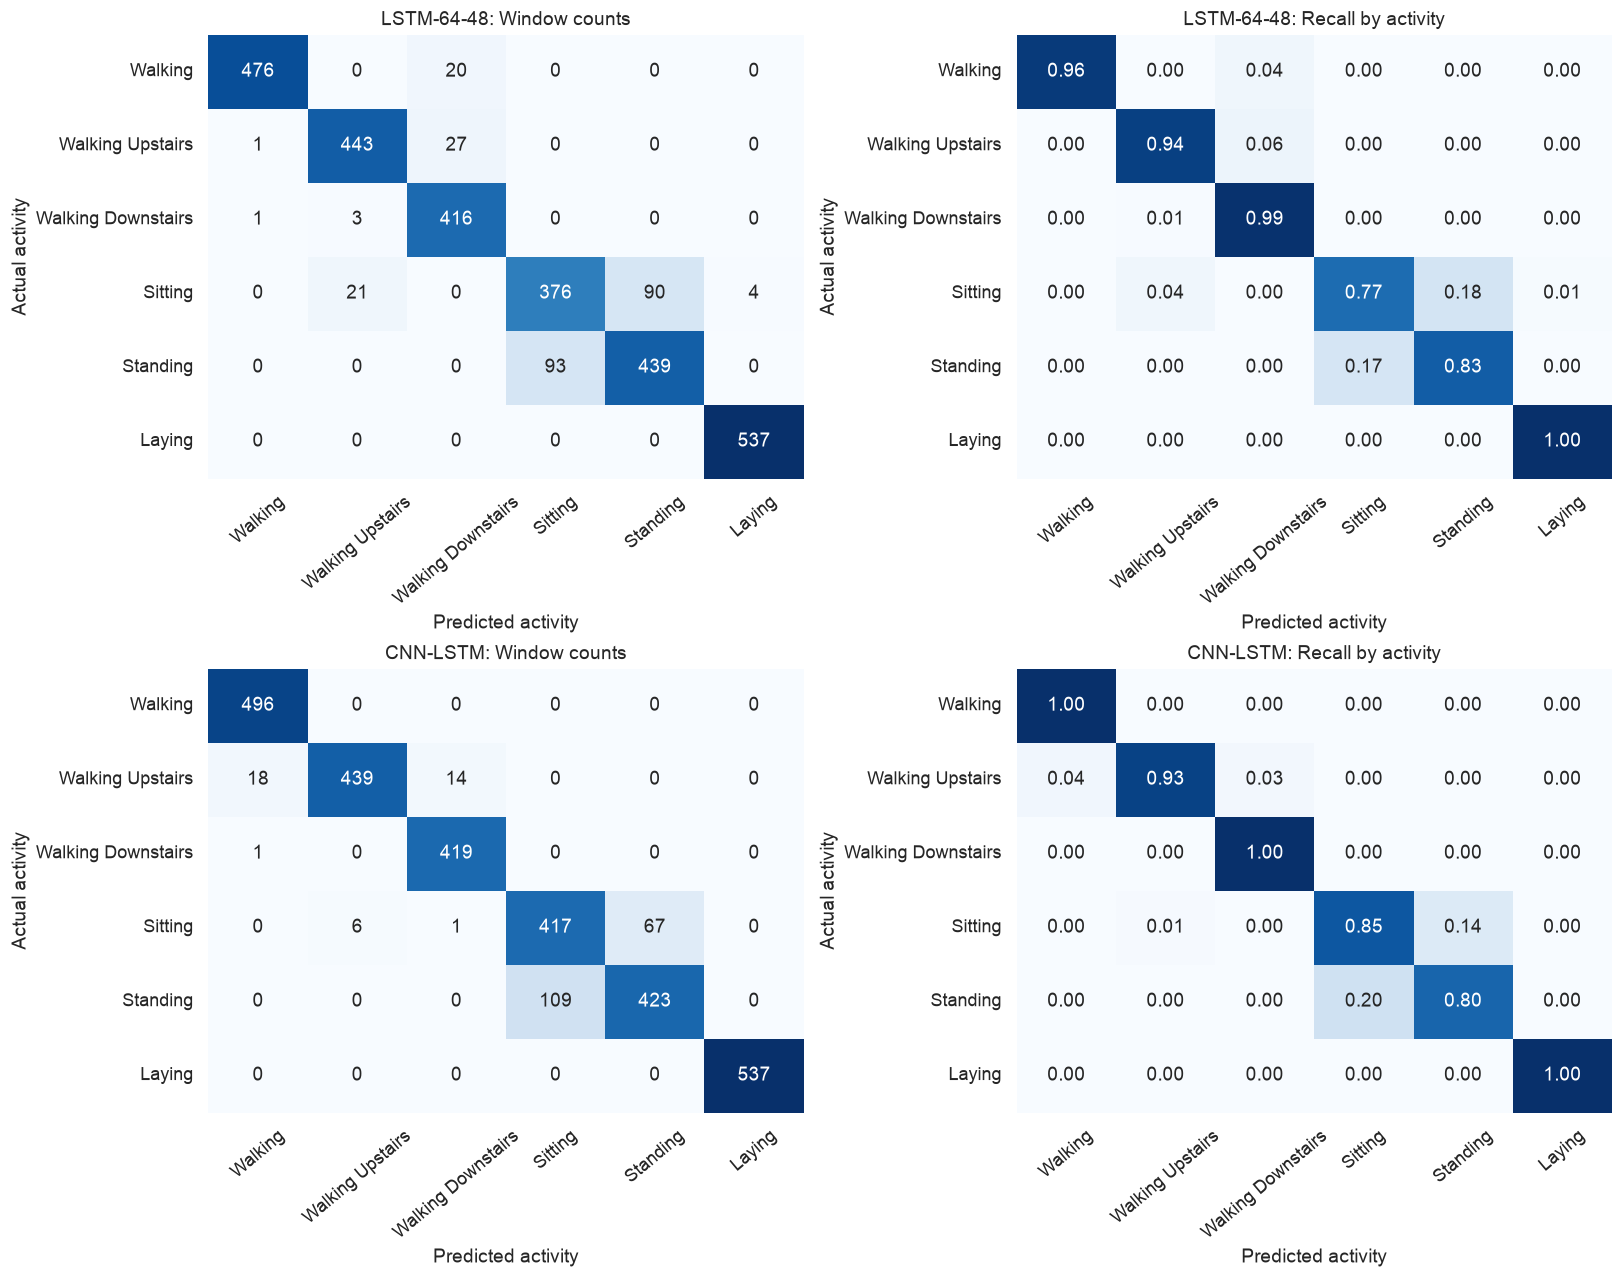

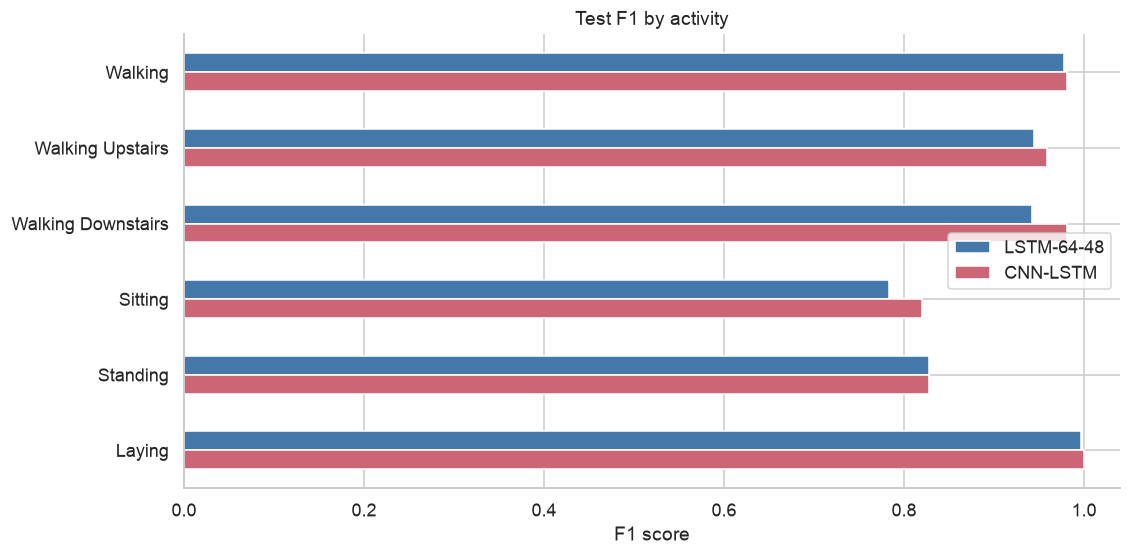

In [29]:
lstm_test_prob = selected_lstm.predict((X_keras_test - lstm_mean) / lstm_std, verbose=0)
lstm_test_pred = lstm_test_prob.argmax(axis=1)
predictions = {selected_lstm_name: lstm_test_pred, "CNN-LSTM": test_pred}
result_rows = [
    {
        "Model": name,
        "Accuracy": accuracy_score(test_true, prediction),
        "Macro-F1": f1_score(
            test_true, prediction, labels=np.arange(6), average="macro", zero_division=0
        ),
    }
    for name, prediction in predictions.items()
]
test_results = pd.DataFrame(result_rows).set_index("Model")
display(test_results.style.format("{:.4f}"))

fig, axes = plt.subplots(2, 2, figsize=(14, 11), layout="constrained")
for row, (name, prediction) in enumerate(predictions.items()):
    counts = confusion_matrix(test_true, prediction, labels=np.arange(6))
    recall = counts / counts.sum(axis=1, keepdims=True)
    for column, (matrix, fmt, title) in enumerate(
        [(counts, "d", "Window counts"), (recall, ".2f", "Recall by activity")]
    ):
        ax = axes[row, column]
        sns.heatmap(
            matrix,
            annot=True,
            fmt=fmt,
            cmap="Blues",
            ax=ax,
            cbar=False,
            xticklabels=class_names,
            yticklabels=class_names,
            vmin=0,
            vmax=1 if column else None,
        )
        ax.set(title=f"{name}: {title}", xlabel="Predicted activity", ylabel="Actual activity")
        ax.tick_params(axis="x", rotation=40)
        ax.tick_params(axis="y", rotation=0)
plt.show()

class_scores = pd.DataFrame(
    {
        name: f1_score(test_true, pred, labels=np.arange(6), average=None, zero_division=0)
        for name, pred in predictions.items()
    },
    index=class_names,
)
ax = class_scores.plot.barh(figsize=(10, 5), color=["#4477aa", "#cc6677"])
ax.set(title="Test F1 by activity", xlabel="F1 score", ylabel="", xlim=(0, 1.04))
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [30]:
display(
    pd.DataFrame(
        [
            {
                "Model": selected_lstm_name,
                "Trainable parameters": int(
                    sum(np.prod(w.shape) for w in selected_lstm.trainable_weights)
                ),
                "Final epochs": int(selected_epoch_count),
                "Training participants": len(np.unique(subject_train)),
            },
            {
                "Model": "CNN-LSTM",
                "Trainable parameters": sum(
                    p.numel() for p in tuned_model.parameters() if p.requires_grad
                ),
                "Final epochs": int(final_epochs),
                "Training participants": len(np.unique(subject_train)),
            },
        ]
    )
)


,Model,Trainable parameters,Final epochs,Training participants
0,LSTM-64-48,41062,20,21
1,CNN-LSTM,181574,4,21


Both networks classify every laying window correctly. CNN-LSTM also classifies all 496 walking windows correctly. Sitting and standing remain the main difficulty: LSTM exchanges 183 windows between them and CNN-LSTM exchanges 176. CNN-LSTM has higher sitting recall (0.849 versus 0.766), but lower standing recall (0.795 versus 0.825).

The largest per-class F1 differences favour CNN-LSTM for walking downstairs and sitting. Standing F1 remains about 0.828 for both models.

<a id="6-decision-slices-in-the-learned-feature-space"></a>

## 6. Decision slices in the learned feature space

Both networks end with a linear classifier applied to a learned hidden vector. PCA fitted to final-training hidden vectors defines a two-dimensional viewing plane. Grid points are mapped back to the hidden space with omitted components fixed at their training means, then passed through the trained classifier.

The plots are slices of the final layer rather than full boundaries in sensor space. Projected test points retain information outside the plane, so their full prediction can differ from the region underneath. Confidence panels show the largest softmax probability, not calibrated reliability. Each model has different PCA axes, so distances cannot be compared between rows.

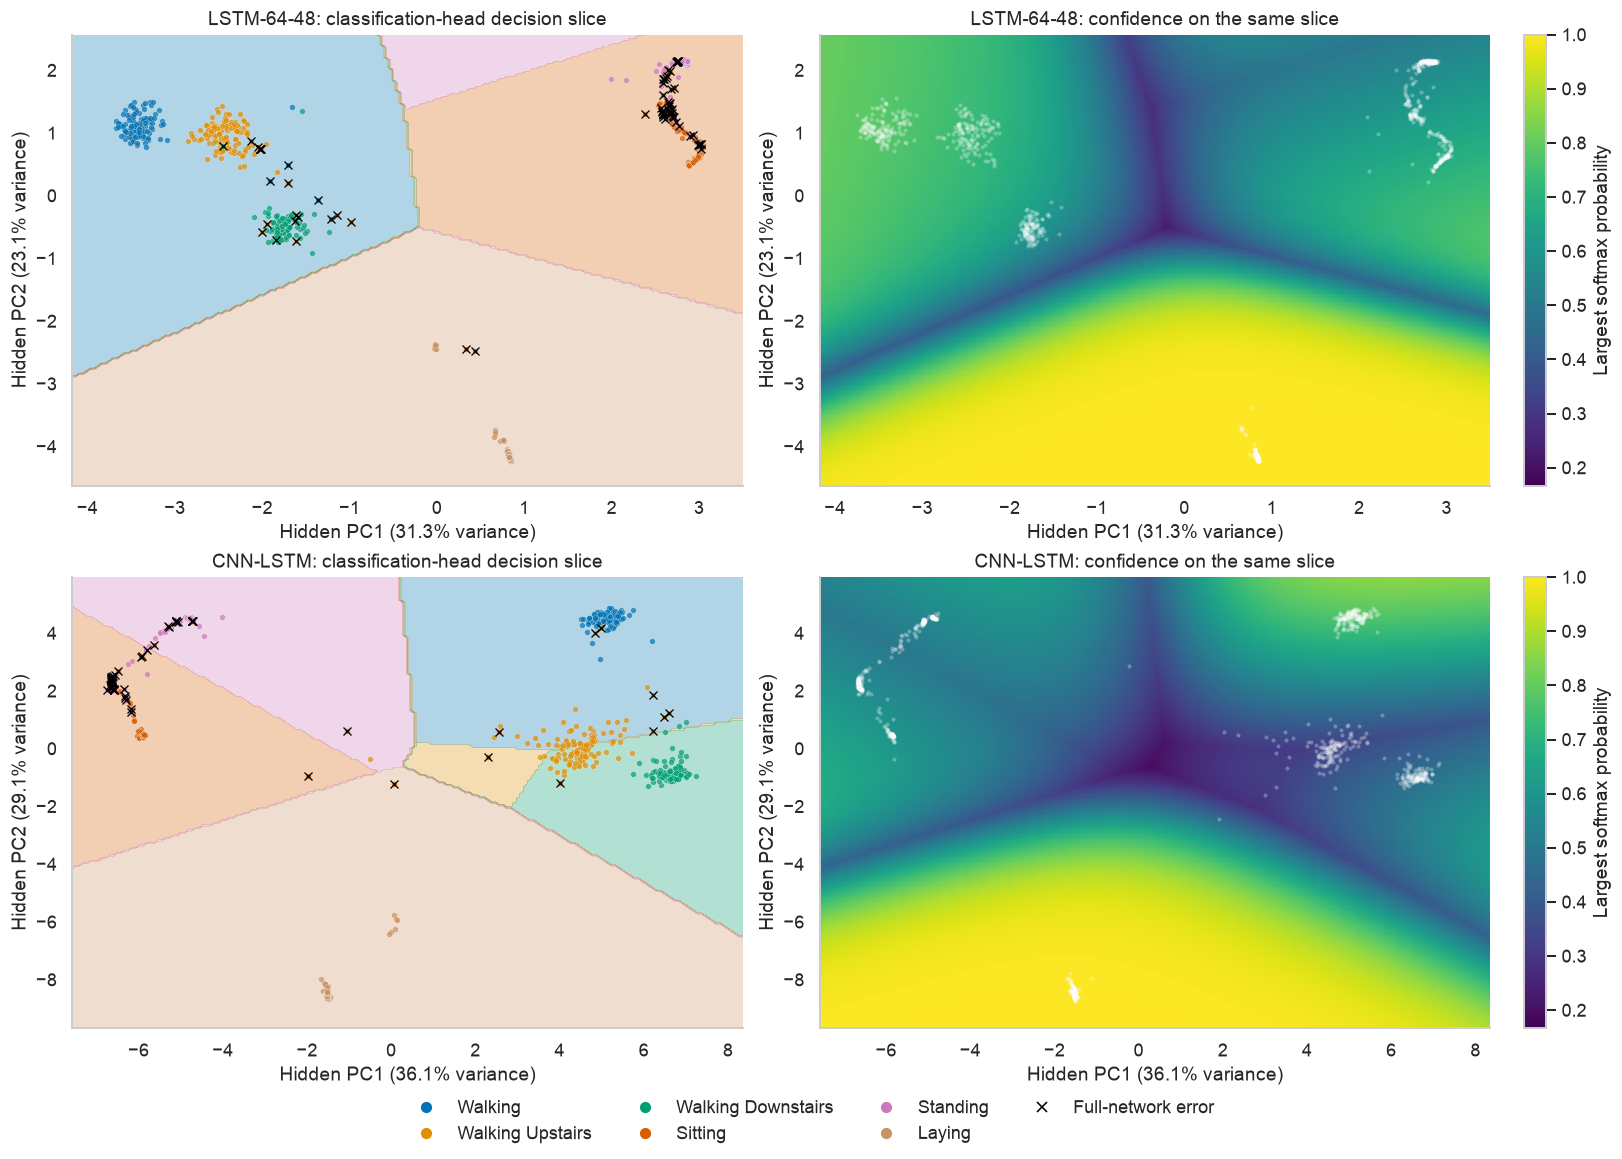

,Variance in plane,Plane/full prediction agreement,Test points outside plotting limits
Model,,,
LSTM-64-48,54.4%,50.5%,0
CNN-LSTM,65.1%,83.3%,0


In [31]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D


def torch_hidden(model, windows, batch_size=256):
    model.eval()
    with torch.no_grad():
        return np.concatenate(
            [
                model.encode(windows[start : start + batch_size]).numpy()
                for start in range(0, len(windows), batch_size)
            ]
        )


lstm_encoder = keras.Model(inputs=selected_lstm.inputs, outputs=selected_lstm.layers[-2].output)
lstm_train_hidden = lstm_encoder.predict(
    (X_keras_train - lstm_mean) / lstm_std, batch_size=256, verbose=0
)
lstm_test_hidden = lstm_encoder.predict(
    (X_keras_test - lstm_mean) / lstm_std, batch_size=256, verbose=0
)
cnn_train_hidden = torch_hidden(tuned_model, X_all_t)
cnn_test_hidden = torch_hidden(tuned_model, X_test_t)
lstm_weights, lstm_bias = selected_lstm.layers[-1].get_weights()
cnn_weights = tuned_model.head[-1].weight.detach().numpy().T
cnn_bias = tuned_model.head[-1].bias.detach().numpy()


def softmax(logits):
    values = np.exp(logits - logits.max(axis=1, keepdims=True))
    return values / values.sum(axis=1, keepdims=True)


# Check that extracted features reproduce each full network's predictions.
np.testing.assert_allclose(
    softmax(lstm_test_hidden @ lstm_weights + lstm_bias), lstm_test_prob, atol=1e-5
)
np.testing.assert_array_equal((cnn_test_hidden @ cnn_weights + cnn_bias).argmax(1), test_pred)

models_for_plot = [
    (
        selected_lstm_name,
        lstm_train_hidden,
        lstm_test_hidden,
        lstm_weights,
        lstm_bias,
        lstm_test_pred,
    ),
    ("CNN-LSTM", cnn_train_hidden, cnn_test_hidden, cnn_weights, cnn_bias, test_pred),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 10), layout="constrained")
cmap = ListedColormap(class_colors)
rng = np.random.default_rng(SEED)
shown = np.sort(rng.choice(len(test_true), min(800, len(test_true)), replace=False))
slice_rows = []
for row, (name, train_hidden, test_hidden, weights, bias, full_prediction) in enumerate(
    models_for_plot
):
    plane = PCA(n_components=2, svd_solver="full").fit(train_hidden)
    train_xy = plane.transform(train_hidden)
    test_xy = plane.transform(test_hidden)
    low, high = train_xy.min(axis=0), train_xy.max(axis=0)
    margin = np.maximum((high - low) * 0.06, 1e-3)
    low, high = low - margin, high + margin
    xx, yy = np.meshgrid(np.linspace(low[0], high[0], 180), np.linspace(low[1], high[1], 180))
    hidden_grid = plane.inverse_transform(np.c_[xx.ravel(), yy.ravel()])
    probabilities = softmax(hidden_grid @ weights + bias)
    regions = probabilities.argmax(axis=1).reshape(xx.shape)
    boundary_ax, confidence_ax = axes[row]
    boundary_ax.contourf(xx, yy, regions, levels=np.arange(7) - 0.5, cmap=cmap, alpha=0.3)
    for label, color in enumerate(class_colors):
        indices = shown[test_true[shown] == label]
        boundary_ax.scatter(
            test_xy[indices, 0],
            test_xy[indices, 1],
            color=color,
            s=13,
            alpha=0.7,
            edgecolor="white",
            linewidth=0.2,
        )
    errors = shown[full_prediction[shown] != test_true[shown]]
    boundary_ax.scatter(
        test_xy[errors, 0], test_xy[errors, 1], marker="x", c="black", s=25, linewidth=0.8
    )
    confidence_image = confidence_ax.pcolormesh(
        xx,
        yy,
        probabilities.max(axis=1).reshape(xx.shape),
        cmap="viridis",
        vmin=1 / 6,
        vmax=1,
        shading="auto",
    )
    confidence_ax.scatter(train_xy[::8, 0], train_xy[::8, 1], c="white", s=3, alpha=0.2)
    fig.colorbar(confidence_image, ax=confidence_ax, label="Largest softmax probability")
    variance = plane.explained_variance_ratio_
    for ax in axes[row]:
        ax.set(
            xlabel=f"Hidden PC1 ({variance[0]:.1%} variance)",
            ylabel=f"Hidden PC2 ({variance[1]:.1%} variance)",
            xlim=(low[0], high[0]),
            ylim=(low[1], high[1]),
        )
        ax.grid(False)
    boundary_ax.set_title(f"{name}: classification-head decision slice")
    confidence_ax.set_title(f"{name}: confidence on the same slice")
    projected_prediction = (plane.inverse_transform(test_xy) @ weights + bias).argmax(axis=1)
    slice_rows.append(
        {
            "Model": name,
            "Variance in plane": float(variance.sum()),
            "Plane/full prediction agreement": float(
                (projected_prediction == full_prediction).mean()
            ),
            "Test points outside plotting limits": int(
                ((test_xy < low) | (test_xy > high)).any(axis=1).sum()
            ),
        }
    )
handles = [
    Line2D([], [], marker="o", linestyle="", color=color, label=name)
    for name, color in zip(class_names, class_colors)
]
handles.append(Line2D([], [], marker="x", linestyle="", color="black", label="Full-network error"))
fig.legend(handles=handles, loc="outside lower center", ncol=4, frameon=False)
plt.show()
display(
    pd.DataFrame(slice_rows)
    .set_index("Model")
    .style.format({"Variance in plane": "{:.1%}", "Plane/full prediction agreement": "{:.1%}"})
)


The first two hidden components retain 54.4% of LSTM variance and 65.1% of CNN-LSTM variance. Slice agreement with full test predictions is 50.5% and 83.3%, respectively, so the LSTM view omits substantial information.

Laying is separate in both views, while sitting and standing remain close. High confidence in sparsely populated regions does not establish reliable classification there.

<a id="7-participant-performance-and-observed-errors"></a>

## 7. Participant performance and observed errors

Participant-level scores show how performance varies across the nine test people without treating overlapping windows as independent. The error table lists the most frequent directed confusions.

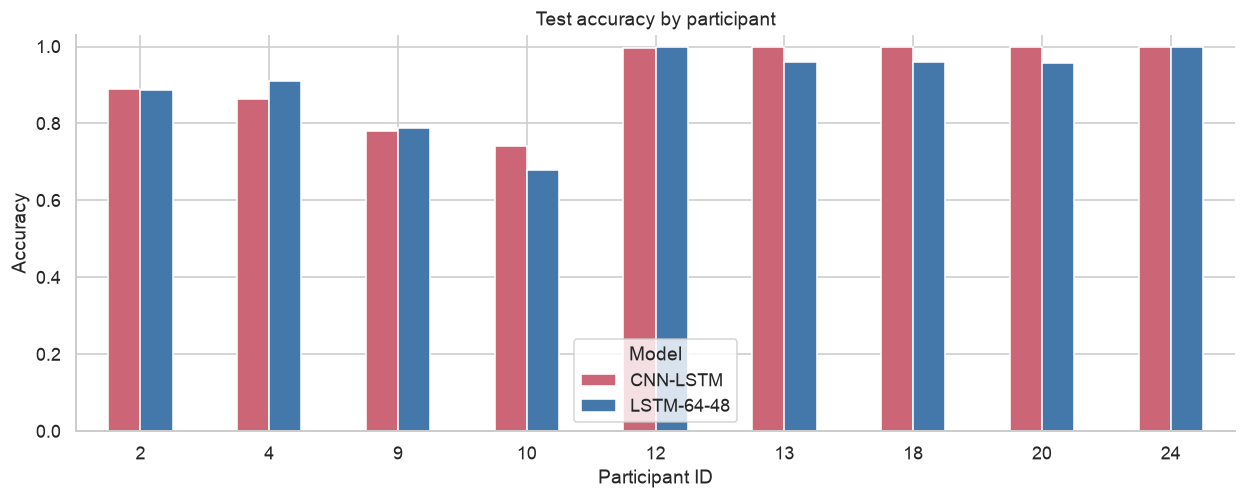

,Model,Actual,Predicted,Windows
0,LSTM-64-48,Standing,Sitting,93
1,LSTM-64-48,Sitting,Standing,90
2,LSTM-64-48,Walking Upstairs,Walking Downstairs,27
3,CNN-LSTM,Standing,Sitting,109
4,CNN-LSTM,Sitting,Standing,67
5,CNN-LSTM,Walking Upstairs,Walking,18


### Results summary

**LSTM-64-48** achieved 91.18% accuracy and 0.9119 macro-F1. Participant accuracy ranged from 68.03% to 100.00%.

**CNN-LSTM** achieved 92.67% accuracy and 0.9281 macro-F1. Participant accuracy ranged from 74.15% to 100.00%.

The largest directed confusion in the two error tables is Standing classified as Sitting by CNN-LSTM (109 windows).

Both models use the same selection split and the same final training participants. Their architecture searches have different budgets. These scores describe one seeded run on the UCI HAR benchmark. The decision slices explain the final classification layers on two hidden dimensions; the measured test scores use the complete networks and original signal windows.

In [32]:
participant_rows = []
error_rows = []
for name, prediction in predictions.items():
    for subject in np.unique(subject_test):
        mask = subject_test == subject
        participant_rows.append(
            {
                "Model": name,
                "Participant": int(subject),
                "Accuracy": accuracy_score(test_true[mask], prediction[mask]),
                "Macro-F1": f1_score(
                    test_true[mask],
                    prediction[mask],
                    labels=np.arange(6),
                    average="macro",
                    zero_division=0,
                ),
            }
        )
    matrix = confusion_matrix(test_true, prediction, labels=np.arange(6))
    np.fill_diagonal(matrix, 0)
    for index in np.argsort(matrix.ravel())[::-1][:3]:
        actual, predicted = np.unravel_index(index, matrix.shape)
        if matrix[actual, predicted] == 0:
            continue
        error_rows.append(
            {
                "Model": name,
                "Actual": class_names[actual],
                "Predicted": class_names[predicted],
                "Windows": int(matrix[actual, predicted]),
            }
        )
participant_results = pd.DataFrame(participant_rows)
ax = participant_results.pivot(index="Participant", columns="Model", values="Accuracy").plot.bar(
    figsize=(11, 4.5), color=["#cc6677", "#4477aa"]
)
ax.set(
    title="Test accuracy by participant", xlabel="Participant ID", ylabel="Accuracy", ylim=(0, 1.03)
)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
display(pd.DataFrame(error_rows))

summary_lines = ["### Results summary"]
for name in predictions:
    metrics = test_results.loc[name]
    subjects = participant_results[participant_results.Model == name]
    summary_lines.append(
        f"**{name}** achieved {metrics['Accuracy']:.2%} accuracy and {metrics['Macro-F1']:.4f} macro-F1. "
        f"Participant accuracy ranged from {subjects.Accuracy.min():.2%} to {subjects.Accuracy.max():.2%}."
    )
if error_rows:
    largest_error = max(error_rows, key=lambda row: row["Windows"])
    summary_lines.append(
        f"The largest directed confusion in the two error tables is {largest_error['Actual']} classified as "
        f"{largest_error['Predicted']} by {largest_error['Model']} ({largest_error['Windows']} windows)."
    )
else:
    summary_lines.append("Neither model misclassified a test window in this run.")
summary_lines.append(
    "Both models use the same selection split and the same final training participants. Their architecture searches have different budgets. "
    "These scores describe one seeded run on the UCI HAR benchmark. The decision slices explain the final classification layers on two hidden dimensions; "
    "the measured test scores use the complete networks and original signal windows."
)
display(Markdown("\n\n".join(summary_lines)))


### 7.1. Saved evaluation

The saved artifact contains predictions, selection records and source fingerprints. Bootstrap intervals resample complete test participants and are conditional on the fitted models; they exclude retraining and selection variation.

In [33]:
import json
from har_pipeline import find_data_file
from har_evaluation import evaluate_by_subject, run_provenance

artifacts_dir = project_root / "artifacts"
artifacts_dir.mkdir(exist_ok=True)
activity_names = np.asarray(ACTIVITIES)
actual_names = activity_names[test_true]
lstm_names = activity_names[lstm_test_pred]
cnn_names = activity_names[test_pred]
lstm_metrics = evaluate_by_subject(actual_names, lstm_names, subject_test, ACTIVITIES, seed=SEED)
lstm_metrics.update({"name": selected_lstm_name, "epochs": int(selected_epoch_count)})
cnn_metrics = evaluate_by_subject(actual_names, cnn_names, subject_test, ACTIVITIES, seed=SEED)
cnn_metrics.update({"name": "CNN-LSTM", "config": best_config, "epochs": int(final_epochs)})
neural_metrics = {
    "schema_version": 2,
    "provenance": run_provenance(project_root, "NN.ipynb", find_data_file(), SEED),
    "training_subjects": int(len(np.unique(subject_train))),
    "test_subjects": int(len(np.unique(subject_test))),
    "selection_metric": "prediction cross-entropy on held-out training participants",
    "selection_subjects": {
        "fit": np.unique(subject_train[train_idx]).tolist(),
        "validation": np.unique(subject_train[val_idx]).tolist(),
    },
    "lstm": lstm_metrics,
    "cnn_lstm": cnn_metrics,
    "lstm_selection": {
        name: {
            key: float(value) if key != "best_epoch" else int(value)
            for key, value in result.items()
            if key != "history"
        }
        for name, result in lstm_runs.items()
    },
    "cnn_lstm_selection": tuning_results,
}
(artifacts_dir / "nn_results.json").write_text(
    json.dumps(neural_metrics, indent=2, allow_nan=False) + "\n"
)
pd.DataFrame(
    {
        "row": np.arange(len(test_true)),
        "subject": subject_test,
        "actual": actual_names,
        "lstm_prediction": lstm_names,
        "cnn_lstm_prediction": cnn_names,
    }
).to_csv(artifacts_dir / "nn_predictions.csv", index=False)
print("Saved neural metrics, selection records and test predictions.")

interval_rows = []
for metrics in [lstm_metrics, cnn_metrics]:
    for metric, bounds in metrics["subject_bootstrap_95_percentile"].items():
        interval_rows.append(
            {
                "Model": metrics["name"],
                "Metric": metric,
                "Estimate": metrics[metric],
                "95% lower": bounds[0],
                "95% upper": bounds[1],
            }
        )
display(
    pd.DataFrame(interval_rows).style.format(
        {"Estimate": "{:.4f}", "95% lower": "{:.4f}", "95% upper": "{:.4f}"}
    )
)


Saved neural metrics, selection records and test predictions.


,Model,Metric,Estimate,95% lower,95% upper
0,LSTM-64-48,accuracy,0.9118,0.8363,0.9657
1,LSTM-64-48,macro_f1,0.9119,0.8328,0.9668
2,CNN-LSTM,accuracy,0.9267,0.8555,0.9792
3,CNN-LSTM,macro_f1,0.9281,0.8526,0.9798


### 7.2. Comparison with engineered-feature models

All models use the same 21 training and nine test participants. Classical selection uses five grouped folds and macro-F1, while neural selection uses one participant split and cross-entropy. Different inputs and tuning budgets mean the table compares complete workflows rather than isolating architecture alone.

In [34]:
from har_evaluation import results_are_current

classical_path = artifacts_dir / "har_results.json"
if not classical_path.is_file():
    raise FileNotFoundError("Run HAR.ipynb first to create the classical results.")
classical_results = json.loads(classical_path.read_text())
if not results_are_current(classical_results, project_root, find_data_file()):
    raise ValueError("Classical results are stale. Rerun HAR.ipynb before this comparison.")
classical_predictions = pd.read_csv(artifacts_dir / "har_predictions.csv")
np.testing.assert_array_equal(classical_predictions["row"], np.arange(len(test_true)))
np.testing.assert_array_equal(classical_predictions["subject"], subject_test)
np.testing.assert_array_equal(classical_predictions["actual"], actual_names)
for column, saved in [
    ("selected_prediction", classical_results["classical"]),
    ("rbf_prediction", classical_results["rbf_followup"]),
    ("logistic_prediction", classical_results["logistic"]),
]:
    np.testing.assert_allclose(
        accuracy_score(actual_names, classical_predictions[column]), saved["accuracy"]
    )
    np.testing.assert_allclose(
        f1_score(actual_names, classical_predictions[column], average="macro"), saved["macro_f1"]
    )
comparison_rows = []
for name, inputs, metrics in [
    ("Linear SVM (CV selection)", "Engineered features", classical_results["classical"]),
    ("RBF SVM", "Engineered features", classical_results["rbf_followup"]),
    ("Logistic regression", "Engineered features", classical_results["logistic"]),
    (selected_lstm_name, "Sensor windows", lstm_metrics),
    ("CNN-LSTM", "Sensor windows", cnn_metrics),
]:
    comparison_rows.append(
        {
            "Model": name,
            "Input": inputs,
            "Accuracy": metrics["accuracy"],
            "Macro-F1": metrics["macro_f1"],
            "Mean participant accuracy": metrics["mean_subject_accuracy"],
        }
    )
baseline_prediction = classical_predictions["baseline_prediction"]
comparison_rows.append(
    {
        "Model": "Majority baseline",
        "Input": "Training label frequency",
        "Accuracy": accuracy_score(actual_names, baseline_prediction),
        "Macro-F1": f1_score(actual_names, baseline_prediction, average="macro"),
        "Mean participant accuracy": np.mean(
            [
                accuracy_score(
                    actual_names[subject_test == s], baseline_prediction[subject_test == s]
                )
                for s in np.unique(subject_test)
            ]
        ),
    }
)
project_comparison = pd.DataFrame(comparison_rows)
display(
    project_comparison.style.format(
        {"Accuracy": "{:.2%}", "Macro-F1": "{:.4f}", "Mean participant accuracy": "{:.2%}"}
    )
)
difference = cnn_metrics["accuracy"] - lstm_metrics["accuracy"]
display(
    Markdown(
        f"CNN-LSTM changes test accuracy by **{100*difference:+.2f} percentage points** relative to the tested LSTM. "
        "The engineered-feature models remain strong comparators. Overlapping participant intervals are not a test of a model difference. "
        "Independent repetitions are needed to assess how stable this ranking is."
    )
)


,Model,Input,Accuracy,Macro-F1,Mean participant accuracy
0,Linear SVM (CV selection),Engineered features,93.65%,0.9354,93.40%
1,RBF SVM,Engineered features,94.47%,0.9438,94.20%
2,Logistic regression,Engineered features,94.47%,0.9446,94.16%
3,LSTM-64-48,Sensor windows,91.18%,0.9119,90.49%
4,CNN-LSTM,Sensor windows,92.67%,0.9281,91.94%
5,Majority baseline,Training label frequency,18.22%,0.0514,18.19%


CNN-LSTM changes test accuracy by **+1.49 percentage points** relative to the tested LSTM. The engineered-feature models remain strong comparators. Overlapping participant intervals are not a test of a model difference. Independent repetitions are needed to assess how stable this ranking is.

### Overall conclusion

- LSTM reaches 91.18% test accuracy and 0.9119 macro-F1.
- CNN-LSTM reaches 92.67% accuracy and 0.9281 macro-F1 in this run.
- Sitting and standing remain difficult, and performance varies across participants. These errors would affect a daily activity summary even when walking is recognised correctly.
- Engineered-feature models remain strong on this benchmark.
- Use beyond the recorded conditions requires evaluation on new data.

<a id="8-limitations"></a>

## 8. Limitations

- One seed and one participant-disjoint validation split do not measure training stability.
- Nine test participants produce wide uncertainty intervals.
- Different tuning budgets limit direct LSTM and CNN-LSTM comparison.
- Two-dimensional decision slices omit information from the full hidden space.
- Earlier test-set exposure makes the scores benchmark results rather than fresh external validation.
- One phone position and six activities do not establish fall detection or deployment performance.

<a id="9-future-work"></a>

## 9. Future work

- Repeat training across seeds and participant splits.
- Investigate sitting and standing errors using gravity and orientation signals.
- Compare standalone CNN, LSTM, CNN-LSTM and CNN-GRU models under equal tuning budgets.
- Test probability calibration and deployment cost.
- Evaluate fixed models on new participants, devices and phone positions.

## References

- Reyes-Ortiz, J., Anguita, D., Ghio, A., Oneto, L., and Parra, X. (2013). *Human Activity Recognition Using Smartphones*. [UCI dataset and documentation](https://doi.org/10.24432/C54S4K).
- Keras documentation: [LSTM](https://keras.io/api/layers/recurrent_layers/lstm/) and [EarlyStopping](https://keras.io/api/callbacks/early_stopping/).
- PyTorch documentation: [Conv1d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv1d.html), [LSTM](https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html), and [CrossEntropyLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).